In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2_contingency
import seaborn as sns

# Práctica: Estadística Descriptiva (versión sin soluciones)

Este notebook contiene únicamente los **enunciados** de la práctica de Estadística Descriptiva.
Debe completarse por los estudiantes con su propio código y análisis.

Dataset: `descriptive_practice_dataset_large.csv`


## 1) Exploración inicial
- Cargue el dataset y muestre las primeras filas.
- Identifique tipos de variables y valores faltantes.

In [238]:
# Escriba aquí su código
data = pd.read_csv('descriptive_practice_dataset_large.csv')
data.head(10)

,id,gender,age,marital_status,socioeconomic,education,num_children,height_cm,weight_kg,income_usd,commute_min,ticket_price_usd,satisfaction_1_5,owns_car,uses_public_transport,purchase_amount_usd
0,1,Masculino,37.0,Viudo,Medio,Universitario,1,170.6,50.2,8750.76,69,3.70,1.0,No,Si,9.87
1,2,Femenino,19.0,Soltero,Medio,Universitario,0,174.1,55.6,6346.40,1,3.77,2.0,No,No,4.29
2,3,Femenino,40.0,Casado,Alto,Técnico,1,161.0,65.9,3234.99,17,2.76,4.0,No,Si,19.90
3,4,Femenino,42.0,Soltero,Bajo,Universitario,0,170.3,66.1,7348.40,5,5.40,4.0,No,No,27.62
4,5,Masculino,42.0,Casado,Bajo,Universitario,0,159.5,56.8,11370.62,15,4.88,5.0,No,Si,39.12
5,6,Masculino,48.0,Soltero,Alto,Secundaria,0,170.3,65.1,17868.48,14,0.81,4.0,Si,No,23.29
6,7,Masculino,45.0,Soltero,Medio,Universitario,1,168.5,55.4,10733.22,2,0.47,1.0,No,Si,78.01
7,8,Femenino,41.0,Casado,Medio,Posgrado,1,160.6,59.1,10349.56,3,3.45,4.0,Si,No,2.01
8,9,Femenino,34.0,Soltero,Alto,Técnico,1,182.0,60.0,6213.26,15,4.14,2.0,No,No,28.26
9,10,Femenino,16.0,Soltero,Bajo,Secundaria,1,152.6,66.7,3195.89,2,2.23,4.0,Si,No,24.08


# Tipo de cada variable
- id : Nominal
- gender: Nominal
- age: Escalar discreta
- marital_status: Nominal
- socioeconomic: Ordinal
- education: Nominal
- num_children: Escalar discreta
- height_cm: Escalar continua
- weight_kg: Escalar continua
- income_usd: Escalar continua
- commute_min: Escalar continua
- ticket_price_usd: Escalar continua
- satisfaction_1_5: Ordinal
- owns_car: Nominal
- uses_public_transport: Nominal
- purchase_amount_usd: Escalar continua


# Valores faltantes por columna

In [239]:
data.isna().sum()
#data = data.dropna()

id                        0
gender                    0
age                      20
marital_status            0
socioeconomic             0
education                 0
num_children              0
height_cm                20
weight_kg                 0
income_usd               20
commute_min               0
ticket_price_usd          0
satisfaction_1_5         20
owns_car                  0
uses_public_transport     0
purchase_amount_usd       0
dtype: int64

# Estrategia para tratar valores faltantes

- Se pudiera realizar un promedio de la columna con los valores existentes y asignar ese valor en las posiciones faltantes
    - Media o mediana para variables escalares
    - Moda para variables categóricas
- Se pudiera desarrollar un algoritmo de predicción con machine learning para tomar en cuenta todas las demás columnas y predecir que valor es el mas apropiado en cada variable
- Remover filas con valores faltantes para no afectar el análisis de los datos

In [240]:
data["age"] = data["age"].fillna(np.floor(data["age"].mean()))
data["height_cm"] = data["height_cm"].fillna(data["height_cm"].mean())
data["income_usd"] = data["income_usd"].fillna(data["income_usd"].mean())
data["satisfaction_1_5"] = data["satisfaction_1_5"].fillna(data["satisfaction_1_5"].mode())

## 2) Tablas de frecuencia y gráficos
- Genere tablas de frecuencia absoluta y relativa para variables categóricas.
- Dibuje histogramas para variables numéricas seleccionadas.

# Frecuencias absolutas y relativas

In [241]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['gender'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['gender'].value_counts(normalize=True) * 100)

FRECUENCIA ABSOLUTA
gender
Femenino     496
Masculino    486
Otro          18
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
gender
Femenino     49.6
Masculino    48.6
Otro          1.8
Name: proportion, dtype: float64


In [242]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['socioeconomic'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['socioeconomic'].value_counts(normalize=True)*100)

FRECUENCIA ABSOLUTA
socioeconomic
Medio    513
Bajo     357
Alto     130
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
socioeconomic
Medio    51.3
Bajo     35.7
Alto     13.0
Name: proportion, dtype: float64


In [243]:
# Escriba aquí su código
print("FRECUENCIA ABSOLUTA")
print(data['education'].value_counts())
print("\nFRECUENCIA RELATIVA EN PORCENTAJE")
print(data['education'].value_counts(normalize=True)*100)

FRECUENCIA ABSOLUTA
education
Universitario    391
Secundaria       253
Técnico          212
Posgrado         101
Primaria          43
Name: count, dtype: int64

FRECUENCIA RELATIVA EN PORCENTAJE
education
Universitario    39.1
Secundaria       25.3
Técnico          21.2
Posgrado         10.1
Primaria          4.3
Name: proportion, dtype: float64


# Histogramas

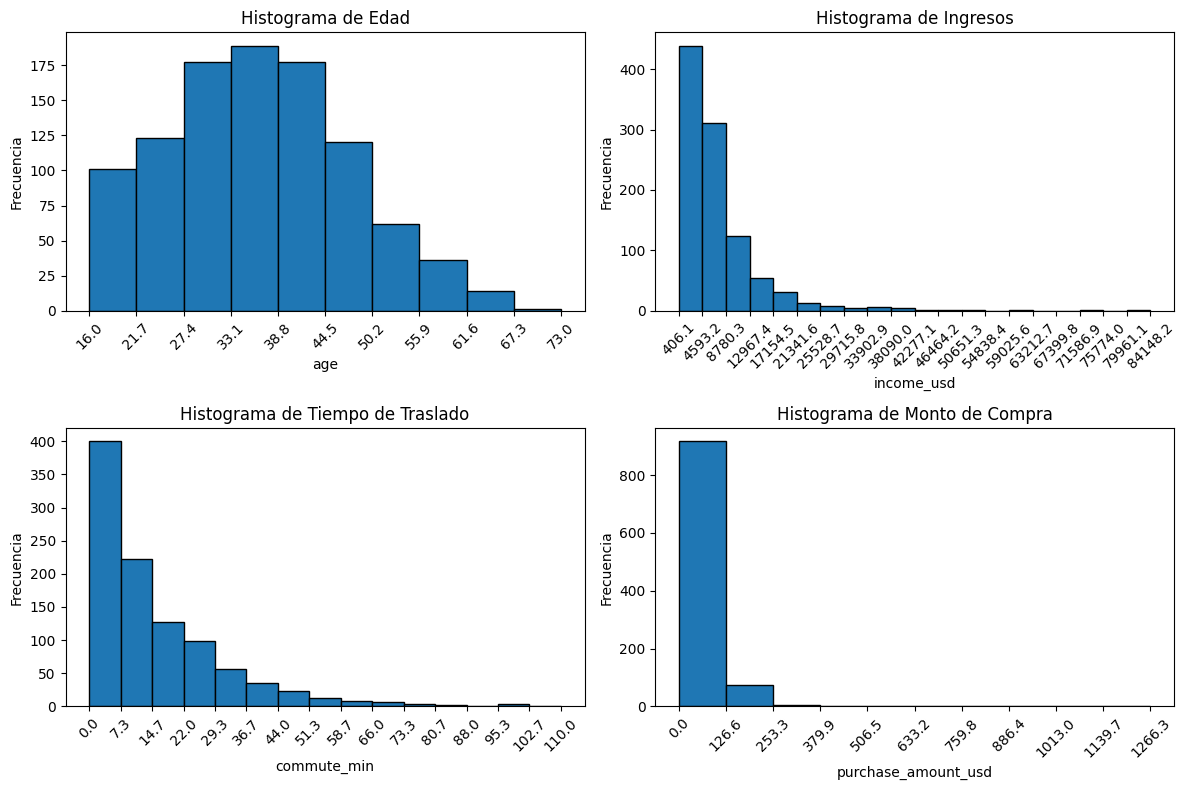

In [257]:
import matplotlib.pyplot as plt
import numpy as np # Added for rounding if needed

variables = [
    ('age', 'Histograma de Edad', 10),
    ('income_usd', 'Histograma de Ingresos', 20),
    ('commute_min', 'Histograma de Tiempo de Traslado', 15),
    ('purchase_amount_usd', 'Histograma de Monto de Compra', 10),
]

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for ax, (column, title, num_bins) in zip(axs.flatten(), variables):
    values = data[column].dropna()
    counts, bin_edges, patches = ax.hist(values, bins=num_bins, edgecolor='black')
    ax.set_xticks(bin_edges)
    tick_labels = [f"{val:.1f}" for val in bin_edges]
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Set titles and labels
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Tabla de frecuencia agrupada

In [245]:
# Tabla de frecuencia agrupada de income con porcentaje por rango
print("FRECUENCIA AGRUPADA DE VARIABLE income")

frecuencia = data['income_usd'].value_counts(bins=35).sort_index()
porcentaje = (frecuencia / len(data) * 100).round(2)

tabla_frecuencia = pd.DataFrame({
    'Frecuencia': frecuencia,
    'Porcentaje (%)': porcentaje
})

print(tabla_frecuencia)

FRECUENCIA AGRUPADA DE VARIABLE income
                        Frecuencia  Porcentaje (%)
(322.387, 2798.759]            228            22.8
(2798.759, 5191.389]           270            27.0
(5191.389, 7584.018]           193            19.3
(7584.018, 9976.648]           113            11.3
(9976.648, 12369.277]           55             5.5
(12369.277, 14761.907]          45             4.5
(14761.907, 17154.536]          22             2.2
(17154.536, 19547.165]          17             1.7
(19547.165, 21939.795]          19             1.9
(21939.795, 24332.424]           3             0.3
(24332.424, 26725.054]           8             0.8
(26725.054, 29117.683]           5             0.5
(29117.683, 31510.313]           1             0.1
(31510.313, 33902.942]           4             0.4
(33902.942, 36295.571]           3             0.3
(36295.571, 38688.201]           3             0.3
(38688.201, 41080.83]            3             0.3
(41080.83, 43473.46]             3         

Las agrupaciones pueden ser engañosas si no se realiza divisiones apropiadas o rangos adecuados de los ingresos, en este caso por ejemplo si dejamos un numero bajo de divisiones no se aprecia el verdadero porcentaje de personas con ingresos bajos.

## 3) Medidas de tendencia central
- Calcule media, mediana, moda e interprete resultados.

In [246]:
variables = ['age', 'income_usd', 'ticket_price_usd']

for var in variables:
    print('-' * 40)
    print(f"Media de {var}: {data[var].mean()}")
    print(f"Mediana de {var}: {data[var].median()}")
    print(f"Moda de {var}: {data[var].mode()[0]}")


----------------------------------------
Media de age: 36.386
Mediana de age: 36.0
Moda de age: 36.0
----------------------------------------
Media de income_usd: 7318.094989795918
Mediana de income_usd: 5203.82
Moda de income_usd: 7318.094989795918
----------------------------------------
Media de ticket_price_usd: 2.46206
Mediana de ticket_price_usd: 2.46
Moda de ticket_price_usd: 0.0


# Interpretación de income_usd

La presencia de asimetria indica que existen valores mucho mas grandes que la mediana que afectan a la media de la variable lo que podria significar valores outliers o personas muy afortunadas (clase alta) que ganan mucho mas que la mayoria de la muestra recogida.

## 4) Medidas de dispersión
- Calcule rango, varianza, desviación estándar, coeficiente de variación.
- Identifique y analice outliers con IQR.

In [247]:
# Escriba aquí su código
# - Calcule rango, varianza, desviación estándar, coeficiente de variación para `income_usd` y `purchase_amount_usd`.#
# - Identifique y comente la presencia de outliers usando IQR y la regla 1.5*IQR.
print("Rango de income_usd:", data["income_usd"].max() - data["income_usd"].min())
print("Varianza de income_usd:", data['income_usd'].var())
print("Desviación estándar de income_usd:", data['income_usd'].std())
print("Coeficiente de variación de income_usd:", (data['income_usd'].std() / data['income_usd'].mean())*100)
print("-"*40)
print("Rango de purchase_amount_usd:", data["purchase_amount_usd"].max() - data["purchase_amount_usd"].min())
print("Varianza de purchase_amount_usd:", data['purchase_amount_usd'].var())
print("Desviación estándar de purchase_amount_usd:", data['purchase_amount_usd'].std())
print("Coeficiente de variación de purchase_amount_usd:", (data['purchase_amount_usd'].std() / data['purchase_amount_usd'].mean())*100)   






Rango de income_usd: 83742.03
Varianza de income_usd: 58446775.11368438
Desviación estándar de income_usd: 7645.049058945559
Coeficiente de variación de income_usd: 104.46774836355
----------------------------------------
Rango de purchase_amount_usd: 1266.29
Varianza de purchase_amount_usd: 5000.547898669771
Desviación estándar de purchase_amount_usd: 70.71455224117432
Coeficiente de variación de purchase_amount_usd: 130.55957588718266


# IQR y regla de IQR*1.5

In [248]:
Q1 = data['income_usd'].quantile(0.25)
Q3 = data['income_usd'].quantile(0.75)
IQR = Q3 - Q1
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
IQR_lower_bound = Q1 - 1.5 * IQR
IQR_upper_bound = Q3 + 1.5 * IQR
print(f"Lower Bound: {IQR_lower_bound}, Upper Bound: {IQR_upper_bound}")
outliers = data[(data['income_usd'] < IQR_lower_bound) | (data['income_usd'] > IQR_upper_bound)]
print(f"Outliers en income_usd:\n{outliers['income_usd'].count()}")

Q1: 2967.005, Q3: 8795.83, IQR: 5828.825
Lower Bound: -5776.232499999999, Upper Bound: 17539.067499999997
Outliers en income_usd:
73


Existen 73 outliers en los datos, especificamente de individuos que podrian estar teniendo ingresos mucho mayores que el resto

## 5) Medidas de posición
- Calcule percentiles y cuartiles y explique su significado.

In [249]:
# Escriba aquí su código
percentiles = [0.10, 0.25, 0.5, 0.75, 0.90]
for p in percentiles:
    print(f"{int(p*100)}: {data['income_usd'].quantile(p)}")

10: 1707.531
25: 2967.005
50: 5203.82
75: 8795.83
90: 14254.375000000002


Cada cuartil significa el porcentaje de inviduos que tienen esa cantidad o menos de ingreso, lo que resulta interesante ver que menos del 25% tienen valores mayores a 10000$ mensuales

## 6) Boxplots
- Cree boxplots para comparar distribuciones entre grupos.

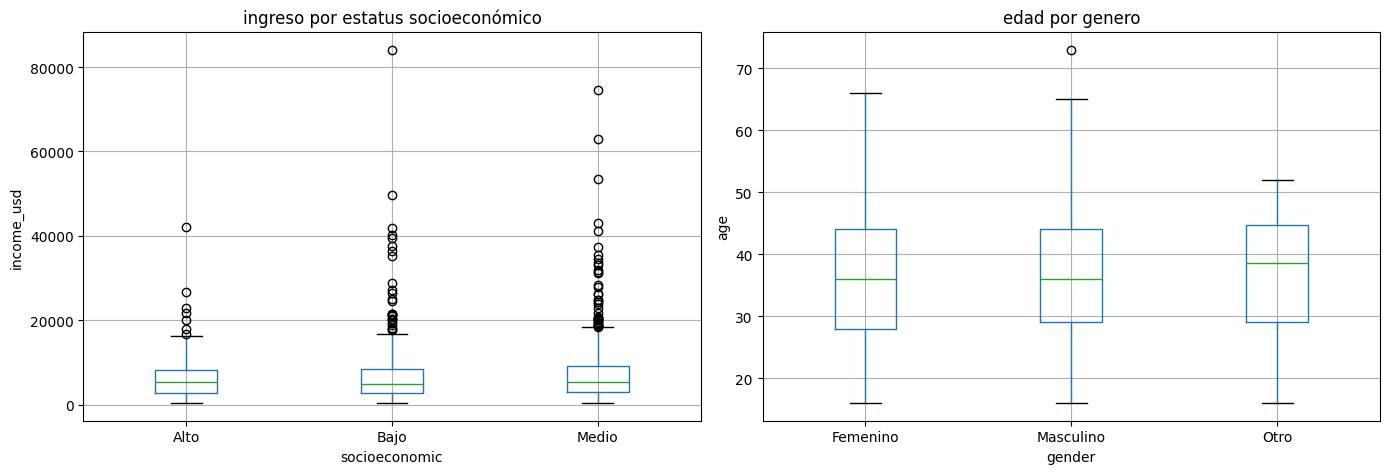

In [250]:
# Boxplot comparativo por variable categórica socioeconomic
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

data.boxplot(column='income_usd', by='socioeconomic', ax=axs[0])
axs[0].set_title('ingreso por estatus socioeconómico')
axs[0].set_xlabel('socioeconomic')
axs[0].set_ylabel('income_usd')

data.boxplot(column='age', by='gender', ax=axs[1])
axs[1].set_title('edad por genero')
axs[1].set_xlabel('gender')
axs[1].set_ylabel('age')


plt.suptitle('')
plt.tight_layout()
plt.show()

## 7) Tablas de contingencia
- Construya tablas de contingencia y realice prueba chi-cuadrado.

In [251]:
# Escriba aquí su código
tabla = pd.crosstab(data['socioeconomic'], data['owns_car'])
#porcentaje por fila
tabla_porcentaje = tabla.div(tabla.sum(axis=1), axis=0) * 100
print(tabla_porcentaje)

owns_car              No         Si
socioeconomic                      
Alto           83.076923  16.923077
Bajo           82.633053  17.366947
Medio          84.990253  15.009747


In [252]:
#chi cuadrado 

chi2, p, dof, expected = chi2_contingency(tabla)
print(f"Chi-cuadrado: {chi2}, p-valor: {p}, grados de libertad: {dof}")


Chi-cuadrado: 0.9408479421108447, p-valor: 0.6247373415759718, grados de libertad: 2


Dado los valores actuales, la prueba de chi cuadrado falla y no se puede establecer que hay una relacion entre el estatus socioeconomico y si se tiene un carro o no

## 8) Correlación y análisis bivariado
- Calcule la matriz de correlación y realice gráficos de dispersión.

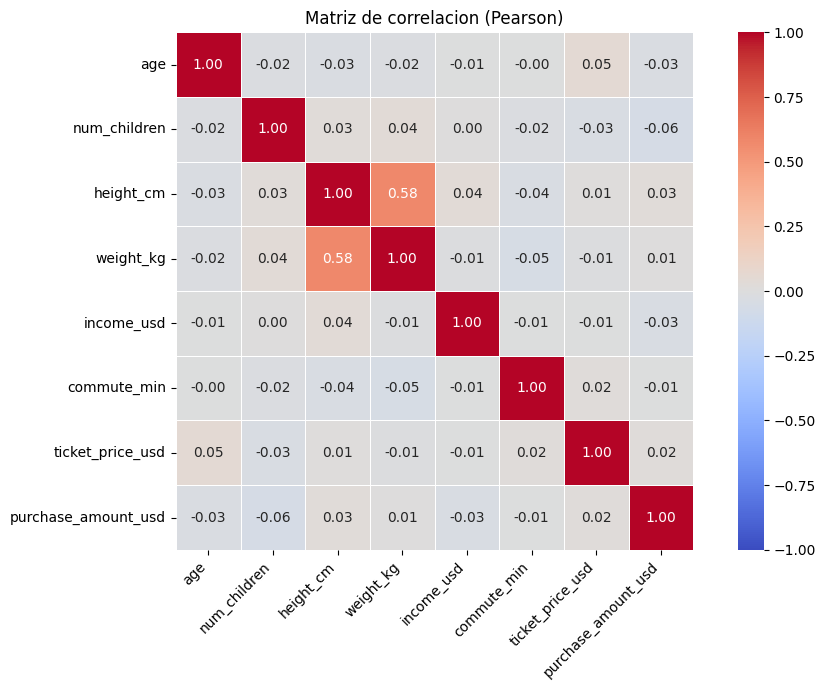

In [253]:
# Matriz de correlacion de Pearson y visualizacion en heatmap
cols = ['age', 'num_children', 'height_cm', 'weight_kg', 'income_usd', 'commute_min', 'ticket_price_usd', 'purchase_amount_usd']
correlation_matrix = data[cols].corr(method='pearson')

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    square=True
)
plt.title('Matriz de correlacion (Pearson)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Text(0.5, 0, 'income_usd')

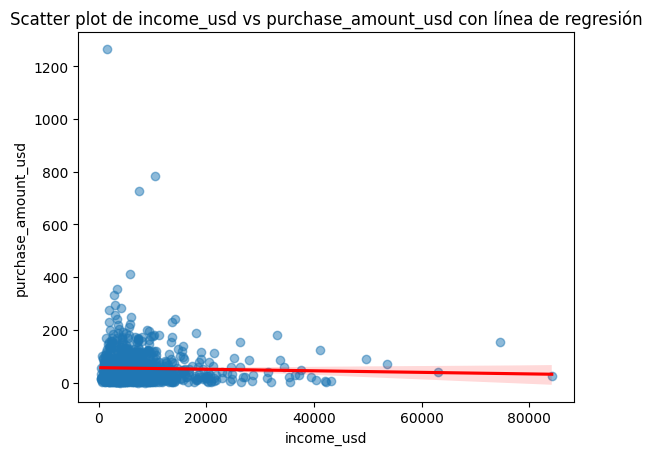

In [254]:
#Grafique un scatter plot de `income_usd` vs `purchase_amount_usd` e incluya línea de regresión (óptimo: utilizando seaborn/regplot).
sns.regplot(x='income_usd', y='purchase_amount_usd', data=data, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter plot de income_usd vs purchase_amount_usd con línea de regresión')
plt.xlabel('income_usd')


In [255]:
#Interprete signo y magnitud del coeficiente de correlación entre `age` e `income_usd`.
correlation_age_income = correlation_matrix.loc['age', 'income_usd']
print(f"Coeficiente de correlación entre age e income_usd: {correlation_age_income:.2f}")

Coeficiente de correlación entre age e income_usd: -0.01


No hay una correlación fuerte entre edad e ingreso económico, aun siendo en signo negativo no es un valor lo suficentemente grande para determinar una dependencia inversa entre ellas

## 9) Informe final
- Redacte una página de conclusiones e interpretación de hallazgos.

El análisis descriptivo de los datos revelan que existen valores faltantes o incompletos en las columnas de edad, altura, ingreso y satisfacción además de existir un desbalance en el ingreso monetario de los individuos, habiendo ciertas personas que ganan por mucho mas de lo común. Tambien se descubre que no existe mayor relacion entre las variables registradas excepto por las medidas de peso y estatura que son valores con una correlación obvia (fisiologia humana). Mediante cuartiles se descubre que existen alrededor de 73 registros en donde su ingreso mensual esta por muy encima de lo esperado, se recomienda normalizar los ingresos mensuales asi como ahondar en los inviduos con mayor gasto en cada una de sus categorias socioeconomicas puesto que se revela que hay varias personas con una categoría media ganando incluso mas al mes que uno de categoria alta.

Finalmente se descubre que el nivel socioeconomico no tiene un efecto directo en si la persona tiene acceso a un vehiculo o no, incluso se descubre que clase media y alta en mayor porcentaje no tiene vehiculo propio.


Para el futuro se pude aprovechar del dataset aplicando técnicas de machine learning para encontrar subgrupos en el tipo de clases socioeconomicas, lo que podría revelar si realmente existe un patrón en los "outliers" previamente mencionados, esto tambien tiene potencial para mejorar la calidad del dataset asignando dichos individuos a la clase que realmente pertenecen.  